In [1]:
%pip install -q pandas matplotlib seaborn scikit-learn xgboost joblib
print('Dependências instaladas no Kernel do Jupyter!')

Note: you may need to restart the kernel to use updated packages.
Dependências instaladas no Kernel do Jupyter!


# Notebook 04: Comparação de Modelos (Árvore vs Floresta vs Boosting)
Objetivo: Treinar, otimizar com GridSearchCV e avaliar 3 modelos de Machine Learning (Árvore de Decisão, Random Forest, XGBoost).

In [2]:
import pandas as pd
import time
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [3]:
# 1. Carregar os Dados
df = pd.read_csv('../data/processed/dataset_rotulado_B_split.csv')

# O XGBoost exige que o alvo seja numérico. Mapeando OK=0, RISCO=1, FALHA=2
mapa_classes = {'OK': 0, 'RISCO': 1, 'FALHA': 2}
df['classe_num'] = df['classe'].map(mapa_classes)

# 2. Selecionar Features
features = [
    'z_robusto', 'aumento_pct', 'jitter_relativo', 'perda_pct',
    'timeout_atual', 'n5_timeout', 'n5_aumento80', 'n5_risco'
]
target = 'classe_num'

# 3. Separar Treino e Validação
df_treino = df[df['split'] == 'treino']
df_val = df[df['split'] == 'validacao']

X_treino = df_treino[features].fillna(0)
y_treino = df_treino[target]

X_val = df_val[features].fillna(0)
y_val = df_val[target]

print(f'Treino: {len(X_treino)} | Validação: {len(X_val)}')

Treino: 86822 | Validação: 34703


## 1. Árvore de Decisão Simples

In [4]:
params_dt = {'max_depth': [3, 4, 5, 7, 10]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), params_dt, cv=3, scoring='f1_macro')

t0 = time.time()
grid_dt.fit(X_treino, y_treino)
tempo_dt = time.time() - t0

melhor_dt = grid_dt.best_estimator_
print(f'Melhor parâmetro: {grid_dt.best_params_}')
print(f'Tempo de Treino DT: {tempo_dt:.2f}s')

Melhor parâmetro: {'max_depth': 7}
Tempo de Treino DT: 3.69s


## 2. Random Forest (Bagging)

In [5]:
params_rf = {'n_estimators': [50, 100], 'max_depth': [4, 7]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params_rf, cv=3, scoring='f1_macro', n_jobs=-1)

t0 = time.time()
grid_rf.fit(X_treino, y_treino)
tempo_rf = time.time() - t0

melhor_rf = grid_rf.best_estimator_
print(f'Melhor parâmetro: {grid_rf.best_params_}')
print(f'Tempo de Treino RF: {tempo_rf:.2f}s')

Melhor parâmetro: {'max_depth': 7, 'n_estimators': 50}
Tempo de Treino RF: 22.29s


## 3. XGBoost (Boosting)

In [6]:
params_xgb = {'n_estimators': [50, 100], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 6]}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), params_xgb, cv=3, scoring='f1_macro', n_jobs=-1)

t0 = time.time()
grid_xgb.fit(X_treino, y_treino)
tempo_xgb = time.time() - t0

melhor_xgb = grid_xgb.best_estimator_
print(f'Melhor parâmetro: {grid_xgb.best_params_}')
print(f'Tempo de Treino XGB: {tempo_xgb:.2f}s')

Melhor parâmetro: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Tempo de Treino XGB: 9.58s


## 4. Avaliação e Geração da Matriz de Confusão

--- BOLETIM XGBOOST ---
              precision    recall  f1-score   support

          OK       1.00      1.00      1.00     29675
       RISCO       0.99      0.99      0.99      2701
       FALHA       0.99      1.00      0.99      2327

    accuracy                           1.00     34703
   macro avg       0.99      1.00      1.00     34703
weighted avg       1.00      1.00      1.00     34703

Tempo para prever 34703 pacotes: 0.0765s


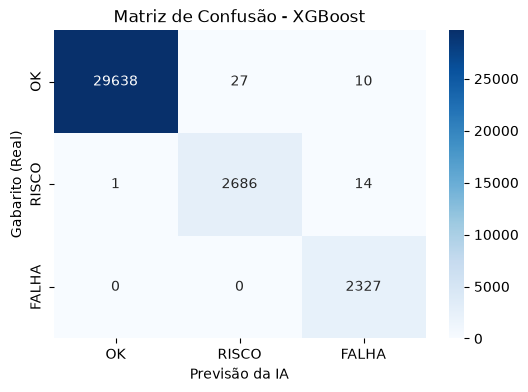

In [7]:
# Avaliar o XGBoost (que geralmente é o mais forte)
t0 = time.time()
previsoes_xgb = melhor_xgb.predict(X_val)
latencia_xgb = time.time() - t0

nomes_classes = ['OK', 'RISCO', 'FALHA']
print('--- BOLETIM XGBOOST ---')
print(classification_report(y_val, previsoes_xgb, target_names=nomes_classes))
print(f'Tempo para prever {len(X_val)} pacotes: {latencia_xgb:.4f}s')

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, previsoes_xgb), annot=True, fmt='d', cmap='Blues', 
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.xlabel('Previsão da IA')
plt.ylabel('Gabarito (Real)')
plt.title('Matriz de Confusão - XGBoost')
plt.savefig('../docs/matriz_xgboost.png', bbox_inches='tight') # Salva a imagem para o artigo!
plt.show()

## 5. Exportação do Campeão para o Artigo (.joblib)

In [8]:
# Salvando o melhor modelo na pasta do projeto
os.makedirs('../producao/modelo', exist_ok=True)
joblib.dump(melhor_xgb, '../producao/modelo/modelo_final.joblib')
print('Modelo campeão exportado para producao/modelo/modelo_final.joblib !')

Modelo campeão exportado para producao/modelo/modelo_final.joblib !
